<a href="https://colab.research.google.com/github/anushabershilla/Data-science-ML/blob/main/Netflixclustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<>:40: SyntaxWarning: invalid escape sequence '\d'
<>:40: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_1514/2278955719.py:40: SyntaxWarning: invalid escape sequence '\d'
  data['duration'] = data['duration'].str.extract('(\d+)')


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   type          8807 non-null   object
 1   release_year  8

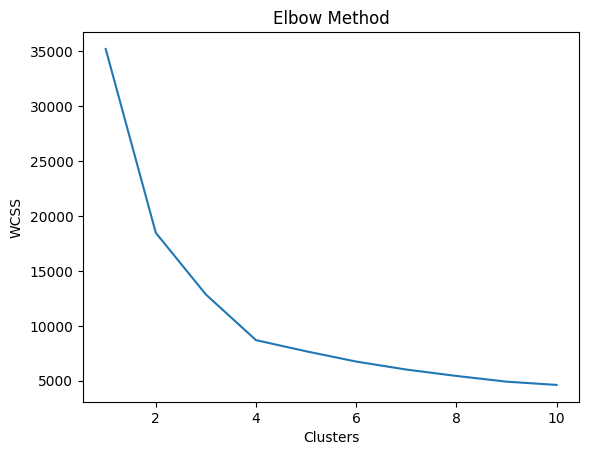

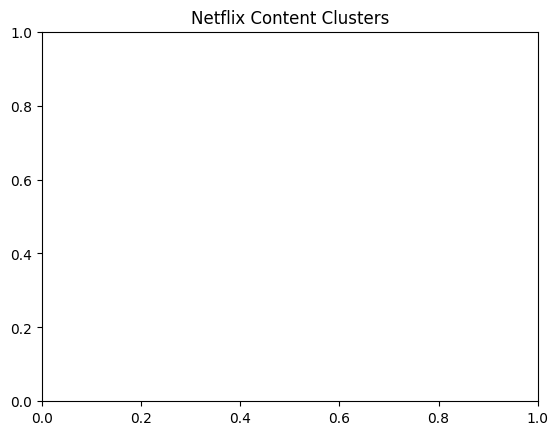

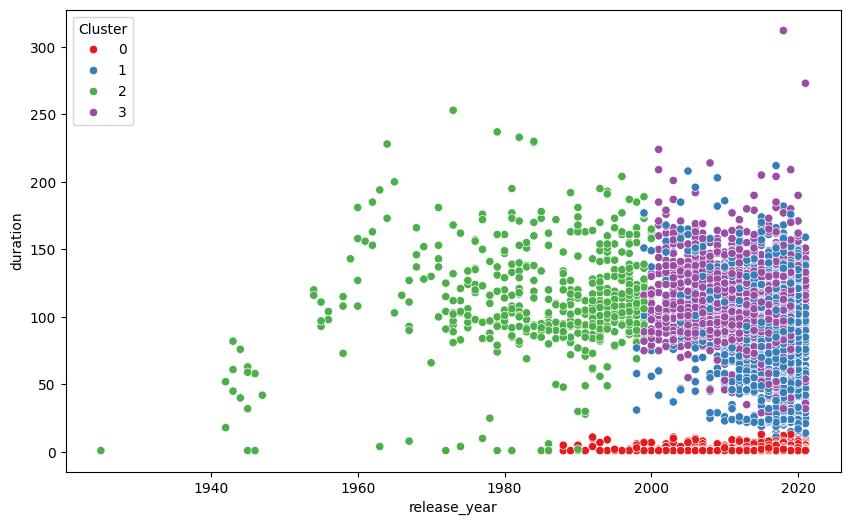

           type  release_year    rating    duration
0  1.000000e+00   2016.864611  7.879654    1.759308
1 -1.171285e-14   2016.575258  8.370790   90.774227
2  3.138075e-02   1985.071130  5.525105  112.548117
3 -1.137979e-14   2014.108972  5.014530  106.120232


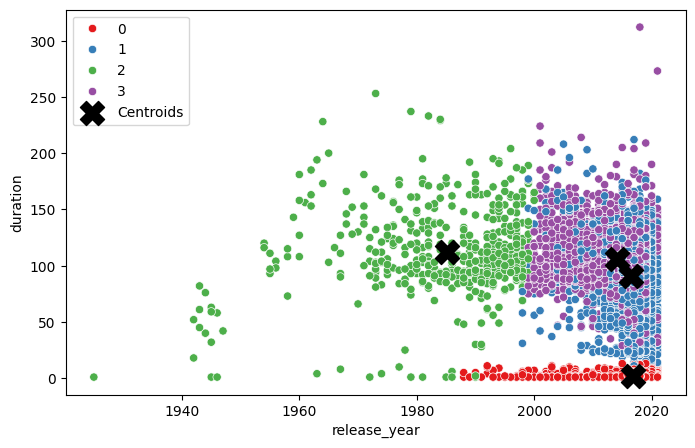

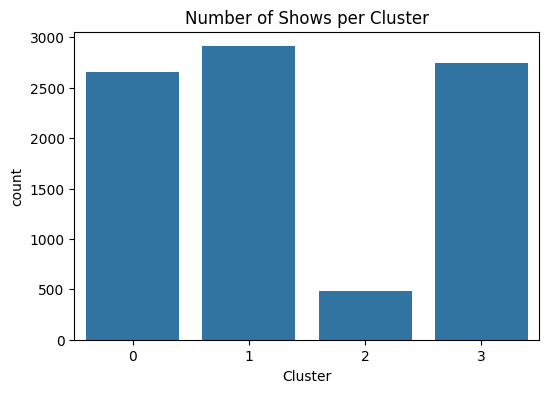

In [ ]:


#import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans

#Read data
df = pd.read_csv('/content/netflix_titles.csv')
display(df.head())
df.describe()
df.info()
df.shape
df.isnull().sum()

# select useful colum
data = df[['type',
           'release_year',
           'rating',
           'duration']]

data.describe()
data.info()
data.isnull().sum()

#Handle missing value (less amount,so drop)
data = data.dropna()

data.isnull().sum()
data.head()

#Clean data or feature engineering

data['duration'] = data['duration'].str.extract('(\d+)')
data['duration'] = data['duration'].astype(int)

# convert categorical column

le = LabelEncoder()

data['type'] = le.fit_transform(data['type'])

data['rating'] = le.fit_transform(data['rating'])

#feature Scaling
scaler = StandardScaler()

scaled_data = scaler.fit_transform(data)

#find best k

wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(scaled_data)

    wcss.append(kmeans.inertia_)

#plot elbow curve
plt.plot(range(1,11), wcss)

plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()

#Train kmean
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

clusters = kmeans.fit_predict(scaled_data)

data['Cluster'] = clusters
data.head()



plt.title("Netflix Content Clusters")
plt.show()

#visualization
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='release_year',
    y='duration',
    hue='Cluster',
    data=data,
    palette='Set1'
)

plt.show()

#find centers

centers = scaler.inverse_transform(
    kmeans.cluster_centers_
)

centers_df = pd.DataFrame(
    centers,
    columns=data.drop('Cluster', axis=1).columns
)

print(centers_df)

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=data,
    x='release_year',
    y='duration',
    hue='Cluster',
    palette='Set1'
)

plt.scatter(
    centers[:,1],   # release_year
    centers[:,3],   # duration
    s=300,
    c='black',
    marker='X',
    label='Centroids'
)

plt.legend()
plt.show()

#Number of shows
plt.figure(figsize=(6,4))

sns.countplot(
    x='Cluster',
    data=data
)

plt.title("Number of Shows per Cluster")
plt.show()